# Gabarito — Circunferência e Círculo

Este notebook traz a resolução comentada dos exercícios de [`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb).

⚠️ **Antes de olhar aqui:** tente resolver os exercícios sozinho no notebook original e use as células de verificação (`assert`) para conferir sua resposta. Volte a este gabarito só depois de tentar — ou se travar de verdade em algum passo.

In [1]:
# Imports necessários para os exercícios abaixo
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Arc, Circle, Polygon, Wedge

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas do notebook principal (reconstruídas aqui).
def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def cruzamento(P, inclinacao_1: float, Q, inclinacao_2: float):
    """Ponto em que a reta que passa por P (com a inclinação `inclinacao_1`, em graus) cruza a reta
    que passa por Q (com a inclinação `inclinacao_2`). Devolve None se as duas retas tiverem a mesma
    direção, porque aí elas não se cruzam num ponto só.

    Por trás, é um sistema linear 2×2 (módulo 03): P + t·u = Q + k·v, com incógnitas t e k.
    """
    matriz = np.column_stack([direcao(inclinacao_1), -direcao(inclinacao_2)])
    if abs(np.linalg.det(matriz)) < 1e-12:
        return None
    t, _ = np.linalg.solve(matriz, np.subtract(Q, P))
    return np.array(P, dtype=float) + t * direcao(inclinacao_1)


def inclinacao_da_perpendicular(inclinacao_r: float) -> float:
    """Inclinação da perpendicular a uma reta de inclinação `inclinacao_r`: girar 90° (a menos de 180°)."""
    return (inclinacao_r + 90) % 180


def projecao_ortogonal(P, ponto_r, inclinacao_r: float) -> np.ndarray:
    """Projeção ortogonal P' de P sobre a reta r (que passa por `ponto_r`, com a inclinação dada):
    o pé da perpendicular a r traçada por P (0407a)."""
    return cruzamento(P, inclinacao_da_perpendicular(inclinacao_r), ponto_r, inclinacao_r)


def distancia_ponto_reta(P, ponto_r, inclinacao_r: float) -> float:
    """Distância de P à reta r: a medida de PP', com P' a projeção ortogonal de P sobre r (0407a)."""
    return math.dist(P, projecao_ortogonal(P, ponto_r, inclinacao_r))


def ponto_medio(P, Q) -> np.ndarray:
    """Ponto médio do segmento PQ: a média das coordenadas (0402a)."""
    return (np.asarray(P, dtype=float) + np.asarray(Q, dtype=float)) / 2


def mediatriz(A, B) -> tuple[np.ndarray, float]:
    """A mediatriz de AB, descrita como toda reta destes notebooks: um ponto (o ponto médio M) e a
    inclinação (0407a)."""
    return ponto_medio(A, B), inclinacao_da_perpendicular(direcao_de(A, B))


def circuncentro(A, B, C) -> np.ndarray:
    """Circuncentro do triângulo ABC: o cruzamento das mediatrizes de AB e de BC (0410a)."""
    return cruzamento(*mediatriz(A, B), *mediatriz(B, C))


def iguais(x: float, y: float) -> bool:
    """Compara duas medidas com uma tolerância pequena (as contas com float têm arredondamentos)."""
    return math.isclose(x, y, rel_tol=1e-9, abs_tol=1e-6)


def desenhar_ponto(ax, p, nome: str = "", cor: str = COR_AVISO, deslocamento=(0.12, 0.15),
                   tamanho_fonte: int = 13) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=7, zorder=6)
    if nome:
        ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=tamanho_fonte,
                fontweight="bold", zorder=7)


def desenhar_reta(ax, P, Q, cor: str = COR_SECUNDARIA, estilo: str = "-", largura: float = 2.0,
                  alpha: float = 0.9) -> None:
    """Desenha a reta inteira que passa por P e por Q (até a borda do gráfico)."""
    ax.axline(tuple(np.asarray(P, dtype=float)), tuple(np.asarray(Q, dtype=float)), color=cor,
              linestyle=estilo, lw=largura, alpha=alpha, zorder=2)


def desenhar_setor(ax, vertice, inicio: float, abertura: float, raio: float = 0.5, cor: str = COR_PONTO,
                   rotulo: str | None = None, marcar_reto: bool = True, raio_rotulo: float | None = None,
                   tamanho_fonte: int = 11) -> None:
    """Pinta o ângulo com vértice em `vertice` que começa na direção `inicio` e gira `abertura`
    graus no sentido anti-horário. O ângulo reto ganha o quadradinho no lugar do arco."""
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90, abs_tol=1e-6):
        lado = 0.6 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        ax.add_patch(Arc(v, 2 * raio, 2 * raio, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia_rotulo = 1.6 * raio if raio_rotulo is None else raio_rotulo
        posicao = v + distancia_rotulo * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=tamanho_fonte, ha="center", va="center", fontweight="bold")


def desenhar_arco(ax, vertice, p, q, **opcoes) -> None:
    """Marca o ângulo de vértice `vertice` formado pelas semirretas que passam por p e por q
    (sempre a abertura menor, entre 0° e 180°). Aceita as mesmas opções de `desenhar_setor`."""
    inicio = direcao_de(vertice, p) % 360
    abertura = (direcao_de(vertice, q) - inicio) % 360
    if abertura > 180:
        inicio, abertura = direcao_de(vertice, q) % 360, 360 - abertura
    desenhar_setor(ax, vertice, inicio, abertura, **opcoes)


def marcar_angulo_reto(ax, vertice, p, q, tamanho: float = 0.3, cor: str = COR_DESTAQUE) -> None:
    """Desenha o quadradinho de ângulo reto no `vertice`, entre as semirretas que passam por p e por q."""
    v = np.array(vertice, dtype=float)
    u = np.subtract(p, v) / np.linalg.norm(np.subtract(p, v))
    w = np.subtract(q, v) / np.linalg.norm(np.subtract(q, v))
    canto = [v, v + tamanho * u, v + tamanho * (u + w), v + tamanho * w]
    ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2, zorder=4))


def marcar_congruentes(ax, P, Q, tracos: int = 1, cor: str = NORD_TEXTO, tamanho: float = 0.16) -> None:
    """Tracinhos no meio do segmento PQ: a marca de segmentos congruentes (0402a)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    u = (Q - P) / np.linalg.norm(Q - P)
    normal = np.array([-u[1], u[0]])
    meio = (P + Q) / 2
    for k in range(tracos):
        centro_traco = meio + (k - (tracos - 1) / 2) * 0.12 * u
        ax.plot(*zip(centro_traco - tamanho * normal, centro_traco + tamanho * normal), color=cor, lw=2,
                zorder=6)


def rotular_segmento(ax, P, Q, texto: str, cor: str, lado: int = 1, distancia: float = 0.3,
                     tamanho: int = 11) -> None:
    """Escreve `texto` junto ao meio do segmento PQ, afastado `distancia` para um dos lados (lado = 1 ou −1)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    normal = np.array([-(Q - P)[1], (Q - P)[0]]) / np.linalg.norm(Q - P)
    ax.text(*((P + Q) / 2 + lado * distancia * normal), texto, color=cor, fontsize=tamanho, fontweight="bold",
            ha="center", va="center", zorder=7)


def rotular_fora(ax, P, texto: str, centro, cor: str = NORD_TEXTO, distancia: float = 0.35,
                 tamanho: int = 12) -> None:
    """Escreve `texto` perto do ponto P, afastado do `centro` (para não ficar em cima da figura)."""
    P = np.asarray(P, dtype=float)
    afastar = P - np.asarray(centro, dtype=float)
    afastar = afastar / np.linalg.norm(afastar) if np.linalg.norm(afastar) > 0 else np.array([0.0, 1.0])
    ax.text(*(P + distancia * afastar), texto, color=cor, fontsize=tamanho, fontweight="bold",
            ha="center", va="center", zorder=7)


def escrever_checklist(ax, itens, titulo: str = "") -> None:
    """Painel de texto com uma linha por item (texto, ok): ✓ verde quando vale, ✗ vermelho quando não (0410a)."""
    ax.set_facecolor(NORD_FUNDO)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    if titulo:
        ax.text(0.0, 0.97, titulo, color=NORD_TEXTO, fontsize=12, fontweight="bold", va="top")
    passo = min(0.13, 0.85 / max(len(itens), 1))
    for k, (texto, ok) in enumerate(itens):
        ax.text(0.0, 0.84 - k * passo, f"{'✓' if ok else '✗'}  {texto}", color=COR_DESTAQUE if ok else COR_ALERTA,
                fontsize=11, va="top")


# Ferramentas novas deste notebook: a circunferência, com UMA cor fixa para cada elemento
COR_CIRCUNFERENCIA = COR_PONTO  # a linha da circunferência
COR_CIRCUNFERENCIA_2 = COR_EXTRA  # a segunda circunferência, quando há duas
COR_CENTRO = NORD_TEXTO  # o centro
COR_RAIO = COR_DESTAQUE  # raios
COR_CORDA = COR_EXTRA  # cordas
COR_DIAMETRO = "#D08770"  # o diâmetro, a maior corda
COR_ARCO = COR_AVISO  # arcos
COR_FLECHA = COR_ALERTA  # a flecha
CORES_POSICAO = {"interior": COR_DESTAQUE, "sobre a circunferência": COR_AVISO, "exterior": COR_ALERTA}
CORES_RETA = {"exterior": COR_ALERTA, "tangente": COR_AVISO, "secante": COR_SECUNDARIA}


def ponto_na_circunferencia(O, r: float, angulo_graus: float) -> np.ndarray:
    """O ponto da circunferência de centro O e raio r que está na direção `angulo_graus`, vista do centro:
    é só andar r a partir de O nessa direção."""
    return np.asarray(O, dtype=float) + r * direcao(angulo_graus)


def desenhar_circunferencia(ax, O, r: float, cor: str = COR_CIRCUNFERENCIA, estilo: str = "-",
                            largura: float = 2.5, preencher: bool = False, opacidade: float = 0.15) -> None:
    """Desenha a circunferência de centro O e raio r (a linha). Com `preencher=True`, pinta também a
    região interna: o círculo."""
    O = tuple(np.asarray(O, dtype=float))
    if preencher:
        ax.add_patch(Circle(O, r, facecolor=cor, alpha=opacidade, edgecolor="none", zorder=1))
    ax.add_patch(Circle(O, r, fill=False, edgecolor=cor, lw=largura, linestyle=estilo, zorder=3))


def desenhar_arco_da_circunferencia(ax, O, r: float, inicio: float, fim: float, cor: str = COR_ARCO,
                                    largura: float = 5.0) -> None:
    """Destaca o arco da circunferência (O, r) que vai da direção `inicio` até a direção `fim`, em graus,
    no sentido anti-horário."""
    ax.add_patch(Arc(tuple(np.asarray(O, dtype=float)), 2 * r, 2 * r, theta1=inicio, theta2=fim, color=cor,
                     lw=largura, zorder=4))


def posicao_ponto(P, O, r: float) -> str:
    """Posição do ponto P em relação à circunferência λ(O, r): 'interior', 'sobre a circunferência'
    ou 'exterior'. Basta comparar a distância OP com o raio."""
    OP = math.dist(P, O)
    if iguais(OP, r):
        return "sobre a circunferência"
    return "interior" if OP < r else "exterior"


def posicao_reta_circunferencia(O, r: float, A, B) -> str:
    """Posição da reta AB em relação à circunferência λ(O, r): 'exterior', 'tangente' ou 'secante'.
    Compara a distância d do centro à reta (0407a) com o raio."""
    d = distancia_ponto_reta(O, A, direcao_de(A, B))
    if iguais(d, r):
        return "tangente"
    return "secante" if d < r else "exterior"


def intersecao_reta_circunferencia(O, r: float, A, B) -> list[np.ndarray]:
    """Pontos comuns da reta AB com a circunferência λ(O, r): nenhum, um ou dois.

    O pé H da perpendicular baixada de O à reta é o ponto médio da corda (seção 2). A partir de H,
    andamos "meia corda" para cada lado, com meia corda = √(r² − d²): é o Teorema de Pitágoras no
    triângulo retângulo OHA (📌 Triângulos Retângulos); aqui só o usamos para desenhar.
    """
    inclinacao = direcao_de(A, B)
    H = projecao_ortogonal(O, A, inclinacao)
    posicao = posicao_reta_circunferencia(O, r, A, B)
    if posicao == "exterior":
        return []
    if posicao == "tangente":
        return [H]
    meia_corda = math.sqrt(r**2 - math.dist(O, H) ** 2)
    return [H - meia_corda * direcao(inclinacao), H + meia_corda * direcao(inclinacao)]


def posicao_circunferencias(O1, r1: float, O2, r2: float) -> str:
    """Posição relativa de λ(O1, r1) e λ(O2, r2), comparando a distância d = O1O2 entre os centros com a
    soma e a diferença dos raios. A ordem das duas circunferências não importa."""
    d = math.dist(O1, O2)
    maior, menor = max(r1, r2), min(r1, r2)
    if iguais(d, 0):
        return "coincidentes" if iguais(r1, r2) else "concêntricas"
    if iguais(d, maior + menor):
        return "tangentes exteriores"
    if iguais(d, maior - menor):
        return "tangentes interiores"
    if d > maior + menor:
        return "exteriores"
    if d < maior - menor:
        return "interiores"
    return "secantes"


def intersecao_circunferencias(O1, r1: float, O2, r2: float) -> list[np.ndarray]:
    """Pontos comuns de λ(O1, r1) e λ(O2, r2): nenhum, um (tangentes) ou dois (secantes).

    Os pontos comuns ficam simétricos em relação à reta dos centros, sobre a perpendicular a ela num
    ponto H. A distância a = O1H sai de aplicar Pitágoras nos triângulos retângulos O1HP e O2HP
    (📌 Triângulos Retângulos e 📌 Geometria Analítica); aqui só usamos a conta para desenhar e conferir.
    """
    posicao = posicao_circunferencias(O1, r1, O2, r2)
    if posicao not in ("secantes", "tangentes exteriores", "tangentes interiores"):
        return []
    O1, O2 = np.asarray(O1, dtype=float), np.asarray(O2, dtype=float)
    d = math.dist(O1, O2)
    u = (O2 - O1) / d  # direção da reta dos centros
    a = (d**2 + r1**2 - r2**2) / (2 * d)
    H = O1 + a * u
    if posicao != "secantes":
        return [H]  # nas tangentes, o ponto comum está SOBRE a reta dos centros
    h = math.sqrt(max(r1**2 - a**2, 0.0))
    normal = np.array([-u[1], u[0]])
    return [H + h * normal, H - h * normal]


def quadrilatero_circunscrito(O, r: float, angulos_tangencia) -> tuple[list[np.ndarray], list[np.ndarray]]:
    """Quadrilátero formado pelas quatro retas tangentes a λ(O, r) nos pontos das direções
    `angulos_tangencia` (em graus, em ordem crescente, com dois pontos vizinhos a menos de 180° um do outro,
    para que as tangentes vizinhas se cruzem).

    A tangente no ponto de direção α é perpendicular ao raio, então tem inclinação α + 90°.
    Devolve (vertices, tangencias): o vértice k é o cruzamento das tangentes nos pontos k e k + 1.
    """
    T = [ponto_na_circunferencia(O, r, a) for a in angulos_tangencia]
    vertices = [cruzamento(T[k], angulos_tangencia[k] + 90, T[(k + 1) % 4], angulos_tangencia[(k + 1) % 4] + 90)
                for k in range(4)]
    return vertices, T


def lados_do_quadrilatero(vertices) -> list[float]:
    """Medidas AB, BC, CD e DA do quadrilátero ABCD."""
    return [math.dist(vertices[k], vertices[(k + 1) % 4]) for k in range(4)]

## Básico

**Exercício 1.** Distâncias de $O = (2, -1)$ a quatro pontos e a posição de cada um em relação à circunferência de raio 5.

ponto,coordenadas,distância ao centro,posição
P1,"(5, 3)",5.000,sobre a circunferência
P2,"(4, 0)",2.236,interior
P3,"(-4, 2)",6.708,exterior
P4,"(2, -6)",5.000,sobre a circunferência


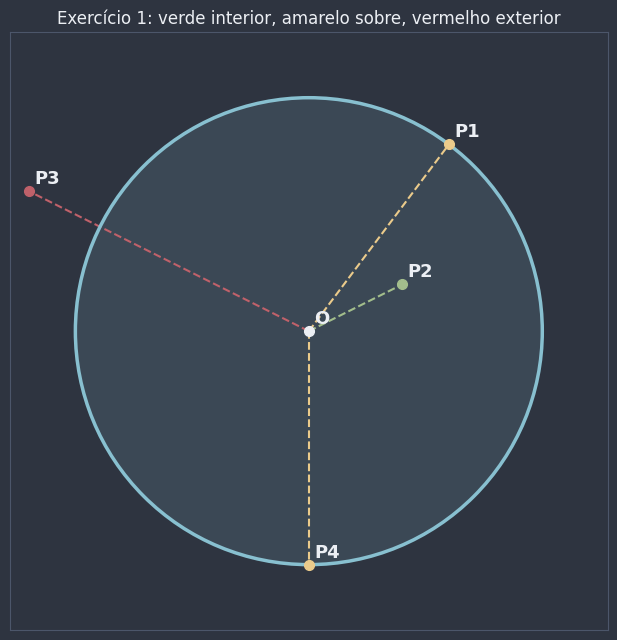

In [2]:
O_ex1, r_ex1 = (2, -1), 5
pontos_ex1 = [(5, 3), (4, 0), (-4, 2), (2, -6)]

# (a) A distância é a "régua" de math.dist. Para P1 = (5, 3): as diferenças são 3 e 4, e a distância é 5.
distancias_ex1 = [math.dist(P, O_ex1) for P in pontos_ex1]

# (b) Compara-se cada distância com o raio, com iguais para o caso "=" (é o que posicao_ponto faz).
posicoes_ex1 = []
for OP in distancias_ex1:
    if iguais(OP, r_ex1):
        posicoes_ex1.append("sobre a circunferência")
    elif OP < r_ex1:
        posicoes_ex1.append("interior")
    else:
        posicoes_ex1.append("exterior")

display(pd.DataFrame({"ponto": ["P1", "P2", "P3", "P4"], "coordenadas": [str(P) for P in pontos_ex1],
                      "distância ao centro": [f"{d:.3f}" for d in distancias_ex1], "posição": posicoes_ex1})
        .style.hide(axis="index"))
# P2 está a √5 ≈ 2,24 (interior), P3 a √45 ≈ 6,71 (exterior); P1 e P4 estão a exatamente 5.

fig, ax = plt.subplots(figsize=(6.5, 6.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-4, -7), (8, 5)], margem=0.4)
desenhar_circunferencia(ax, O_ex1, r_ex1, preencher=True)
desenhar_ponto(ax, O_ex1, "O", cor=COR_CENTRO)
for k, (P, posicao) in enumerate(zip(pontos_ex1, posicoes_ex1)):
    ax.plot(*zip(O_ex1, P), color=CORES_POSICAO[posicao], lw=1.5, linestyle="--")
    desenhar_ponto(ax, P, f"P{k + 1}", cor=CORES_POSICAO[posicao])
ax.set_title("Exercício 1: verde interior, amarelo sobre, vermelho exterior", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

**Exercício 2.** Classificar quatro retas (pela distância $d$ e pelo raio $r$) e seis pares de circunferências (pelos raios e pela distância entre os centros).

In [3]:
pares_ex2 = [(5, 5), (3, 5), (7.5, 7), (0, 2)]
trios_ex2 = [(8, 3, 5), (6, 2, 10), (5, 3, 7), (4, 4, 8), (7, 2, 3), (5, 2, 0)]

# (a) d = r: tangente (1 ponto); d < r: secante (2 pontos); d > r: exterior (nenhum).
#     A última reta (d = 0) passa pelo centro: é secante, e a corda que ela determina é um diâmetro.
retas_ex2 = []
for d, r in pares_ex2:
    retas_ex2.append("tangente" if d == r else ("secante" if d < r else "exterior"))
pontos_comuns_ex2 = [{"tangente": 1, "secante": 2, "exterior": 0}[posicao] for posicao in retas_ex2]

# (b) Compara-se d com a soma e com a diferença dos raios (os números aqui são inteiros, então == é seguro).
circunferencias_ex2 = []
for r1, r2, d in trios_ex2:
    soma, diferenca = r1 + r2, abs(r1 - r2)
    if d == 0:
        posicao = "concêntricas"
    elif d == soma:
        posicao = "tangentes exteriores"
    elif d == diferenca:
        posicao = "tangentes interiores"
    elif d > soma:
        posicao = "exteriores"
    elif d < diferenca:
        posicao = "interiores"
    else:
        posicao = "secantes"
    circunferencias_ex2.append(posicao)

print(retas_ex2, pontos_comuns_ex2)
for (r1, r2, d), posicao in zip(trios_ex2, circunferencias_ex2):
    print(f"r1 = {r1}, r2 = {r2}, d = {d}:  r1 + r2 = {r1 + r2}, r1 − r2 = {abs(r1 - r2)}  ->  {posicao}")

['tangente', 'secante', 'exterior', 'secante'] [1, 2, 0, 2]
r1 = 8, r2 = 3, d = 5:  r1 + r2 = 11, r1 − r2 = 5  ->  tangentes interiores
r1 = 6, r2 = 2, d = 10:  r1 + r2 = 8, r1 − r2 = 4  ->  exteriores
r1 = 5, r2 = 3, d = 7:  r1 + r2 = 8, r1 − r2 = 2  ->  secantes
r1 = 4, r2 = 4, d = 8:  r1 + r2 = 8, r1 − r2 = 0  ->  tangentes exteriores
r1 = 7, r2 = 2, d = 3:  r1 + r2 = 9, r1 − r2 = 5  ->  interiores
r1 = 5, r2 = 2, d = 0:  r1 + r2 = 7, r1 − r2 = 3  ->  concêntricas


## Intermediário

**Exercício 3.** As funções `posicao_reta_ex3` e `posicao_circunferencias_ex3`, escritas do zero.

In [4]:
def posicao_reta_ex3(O, r: float, A, B) -> str:
    # A distância do centro à reta é a da perpendicular (0407a); a reta é descrita por um ponto e a inclinação.
    d = distancia_ponto_reta(O, A, direcao_de(A, B))
    if iguais(d, r):  # iguais, e não ==: as contas com float podem deixar d um fio acima ou abaixo de r
        return "tangente"
    return "secante" if d < r else "exterior"


def posicao_circunferencias_ex3(O1, r1: float, O2, r2: float) -> str:
    d = math.dist(O1, O2)
    maior, menor = max(r1, r2), min(r1, r2)  # a tabela supõe r1 ≥ r2: trocamos se for preciso
    if iguais(d, 0):
        return "concêntricas"
    if iguais(d, maior + menor):
        return "tangentes exteriores"
    if iguais(d, maior - menor):
        return "tangentes interiores"
    if d > maior + menor:
        return "exteriores"
    if d < maior - menor:
        return "interiores"
    return "secantes"


# A ordem dos testes importa: os casos de igualdade (tangências) vêm antes das desigualdades, e o caso d = 0 vem
# antes de todos (com d = 0 e raios iguais, d = r1 − r2 também valeria, mas as circunferências seriam a mesma).
print(posicao_reta_ex3((0, 0), 5, (3, 4), (7, 1)), distancia_ponto_reta((0, 0), (3, 4), direcao_de((3, 4), (7, 1))))
print(posicao_circunferencias_ex3((0, 0), 4, (6, 0), 2), posicao_circunferencias_ex3((2, 0), 2, (0, 0), 4))

tangente 5.0
tangentes exteriores tangentes interiores


**Exercício 4.** Corda, flecha e segmento tangente com a relação $r^2 = d^2 + \left(\frac{c}{2}\right)^2$ (o Teorema de Pitágoras, usado aqui de forma antecipada).

In [5]:
# (a) Metade da corda: 12. Triângulo retângulo de catetos 5 e 12: r² = 25 + 144 = 169.
raio_ex4a = math.sqrt(5**2 + (24 / 2) ** 2)

# (b) d² = r² − (c/2)² = 100 − 36 = 64; a flecha, do lado do arco menor, vai da corda até a circunferência: r − d.
distancia_ex4b = math.sqrt(10**2 - (12 / 2) ** 2)
flecha_ex4b = 10 - distancia_ex4b

# (c) A tangente é perpendicular ao raio: o triângulo OAP é retângulo em A, com hipotenusa PO = 17.
#     PA² = 17² − 8² = 289 − 64 = 225.
tangente_ex4c = math.sqrt(17**2 - 8**2)

# (d) Com a distância d = r − f:  r² = (r − 5)² + 15²  ->  r² = r² − 10r + 25 + 225  ->  10r = 250  ->  r = 25.
#     É a fórmula r = (c²/4 + f²) / (2f) da seção 2.
c_ex4d, f_ex4d = 30, 5
raio_ex4d = (c_ex4d**2 / 4 + f_ex4d**2) / (2 * f_ex4d)

print(f"(a) raio = {raio_ex4a:g} cm")
print(f"(b) distância = {distancia_ex4b:g} cm, flecha = {flecha_ex4b:g} cm")
print(f"(c) segmento tangente PA = {tangente_ex4c:g} cm (e PB também, pelos segmentos tangentes)")
print(f"(d) raio da peça = {raio_ex4d:g} cm  (conferindo: {raio_ex4d**2:g} = {(raio_ex4d - 5)**2:g} + {15**2})")

(a) raio = 13 cm
(b) distância = 8 cm, flecha = 2 cm
(c) segmento tangente PA = 15 cm (e PB também, pelos segmentos tangentes)
(d) raio da peça = 25 cm  (conferindo: 625 = 400 + 225)


**Exercício 5.** O teorema de Pitot: um lado desconhecido, a função de teste e um quadrilátero construído por código.

(a) x = 6
(b) [True, False, True]
    (sem iguais: 1.1 + 2.2 == 1.5 + 1.8 dá False, porque 1.1 + 2.2 = 3.3000000000000003)
(c) AB, BC, CD, DA = [4.8563, 4.2567, 3.4004, 4.0]
    AB + CD = 8.256711  e  BC + DA = 8.256711


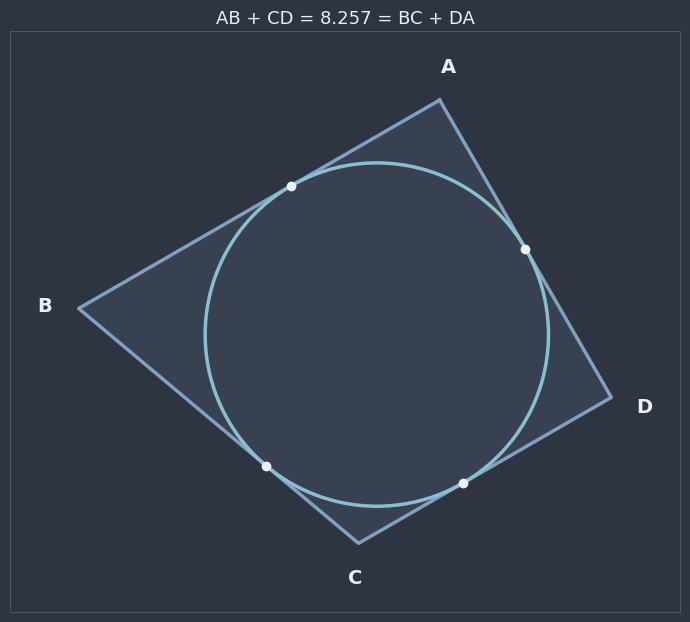

In [6]:
# (a) AB + CD = BC + DA  ->  10 + 8 = x + 12  ->  x = 6.
x_ex5a = 10 + 8 - 12


# (b) Pela recíproca de Pitot, um quadrilátero convexo é circunscritível exatamente quando as somas dos lados opostos
#     são iguais. Com lados decimais (1,1 + 2,2 e 1,5 + 1,8), a conta com float pode não dar exatamente igual: iguais.
def circunscritivel_ex5(AB: float, BC: float, CD: float, DA: float) -> bool:
    return iguais(AB + CD, BC + DA)


# (c) As tangentes nos quatro pontos se cruzam duas a duas e formam o quadrilátero.
vertices_ex5c, tangencias_ex5c = quadrilatero_circunscrito((0, 0), 2, [30, 120, 230, 300])
lados_ex5c = lados_do_quadrilatero(vertices_ex5c)
somas_ex5c = (lados_ex5c[0] + lados_ex5c[2], lados_ex5c[1] + lados_ex5c[3])

print(f"(a) x = {x_ex5a}")
print(f"(b) {[circunscritivel_ex5(*lados) for lados in [(7, 9, 5, 3), (6, 3, 6, 3), (1.1, 1.5, 2.2, 1.8)]]}")
print(f"    (sem iguais: 1.1 + 2.2 == 1.5 + 1.8 dá {1.1 + 2.2 == 1.5 + 1.8}, porque 1.1 + 2.2 = {1.1 + 2.2!r})")
print("(c) AB, BC, CD, DA =", [round(lado, 4) for lado in lados_ex5c])
print(f"    AB + CD = {somas_ex5c[0]:.6f}  e  BC + DA = {somas_ex5c[1]:.6f}")

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, vertices_ex5c, margem=0.8)
ax.add_patch(Polygon(vertices_ex5c, closed=True, facecolor=COR_SECUNDARIA, alpha=0.12, edgecolor="none"))
ax.plot(*zip(*vertices_ex5c, vertices_ex5c[0]), color=COR_SECUNDARIA, lw=2.5)
desenhar_circunferencia(ax, (0, 0), 2)
for T in tangencias_ex5c:
    ax.plot(*T, "o", color=NORD_TEXTO, markersize=6, zorder=6)
for V, nome in zip(vertices_ex5c, "ABCD"):
    rotular_fora(ax, V, nome, (0, 0), distancia=0.4, tamanho=14)
ax.set_title(f"AB + CD = {somas_ex5c[0]:.3f} = BC + DA", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

## Desafio

**Exercício 6.** O centro e o raio da circunferência que passa por três pontos, pelo cruzamento de duas mediatrizes.

centro = (4.0000, 1.0000), raio = 3.0000
pontos colineares: None


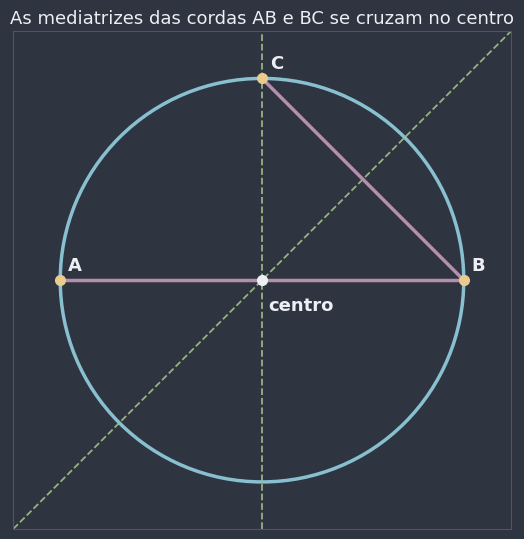

In [7]:
def circunferencia_por_tres_pontos_ex6(A, B, C):
    # AB e BC serão cordas da circunferência procurada, e a mediatriz de toda corda passa pelo centro (seção 2).
    # Então o centro é o cruzamento das duas mediatrizes. Se A, B e C são colineares, as mediatrizes de AB e de BC são
    # perpendiculares à mesma reta, logo paralelas: não se cruzam, e cruzamento devolve None.
    centro = cruzamento(*mediatriz(A, B), *mediatriz(B, C))
    if centro is None:
        return None
    return centro, math.dist(centro, A)  # o raio: a distância do centro a qualquer um dos três pontos


centro_ex6, raio_ex6 = circunferencia_por_tres_pontos_ex6((1, 1), (7, 1), (4, 4))
print(f"centro = ({centro_ex6[0]:.4f}, {centro_ex6[1]:.4f}), raio = {raio_ex6:.4f}")
# A e B estão na horizontal y = 1, então a mediatriz de AB é a vertical x = 4; C = (4, 4) está nela, a 3 unidades
# do centro (4, 1). O triângulo ABC é retângulo em C (os lados CA e CB têm inclinações de 45° e −45°), e o centro
# caiu no ponto médio da hipotenusa AB, como em 0410a.
print("pontos colineares:", circunferencia_por_tres_pontos_ex6((0, 0), (1, 1), (3, 3)))

A6, B6, C6 = (1, 1), (7, 1), (4, 4)
fig, ax = plt.subplots(figsize=(7, 5.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [centro_ex6 - raio_ex6, centro_ex6 + raio_ex6], margem=0.7)
for X, Y in ((A6, B6), (B6, C6)):
    M, inclinacao = mediatriz(X, Y)
    desenhar_reta(ax, M, M + direcao(inclinacao), cor=COR_DESTAQUE, estilo="--", largura=1.3)
    ax.plot(*zip(X, Y), color=COR_CORDA, lw=2.5)
desenhar_circunferencia(ax, centro_ex6, raio_ex6)
for X, nome in ((A6, "A"), (B6, "B"), (C6, "C")):
    desenhar_ponto(ax, X, nome)
desenhar_ponto(ax, centro_ex6, "centro", cor=COR_CENTRO, deslocamento=(0.1, -0.45))
ax.set_title("As mediatrizes das cordas AB e BC se cruzam no centro", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

**Exercício 7.** O número de retas tangentes comuns a duas circunferências em cada posição relativa.

A contagem pensa em dois tipos de tangente comum:
- as **exteriores** (ou "diretas"), que deixam as duas circunferências do **mesmo lado** da reta, como uma correia aberta;
- as **interiores** (ou "cruzadas"), que passam **entre** as duas, deixando cada circunferência de um lado, como uma correia cruzada em "X".

| Posição | Tangentes exteriores | Tangentes interiores | Total |
|---|---|---|---|
| exteriores | 2 | 2 (há espaço entre elas para cruzar) | **4** |
| tangentes exteriores | 2 | 1 (as duas cruzadas viram a tangente no ponto de contato) | **3** |
| secantes | 2 | 0 (não há espaço livre entre elas) | **2** |
| tangentes interiores | 1 (as duas "por fora" se juntam no ponto de contato) | 0 | **1** |
| interiores / concêntricas | 0 (toda tangente da menor corta a maior) | 0 | **0** |

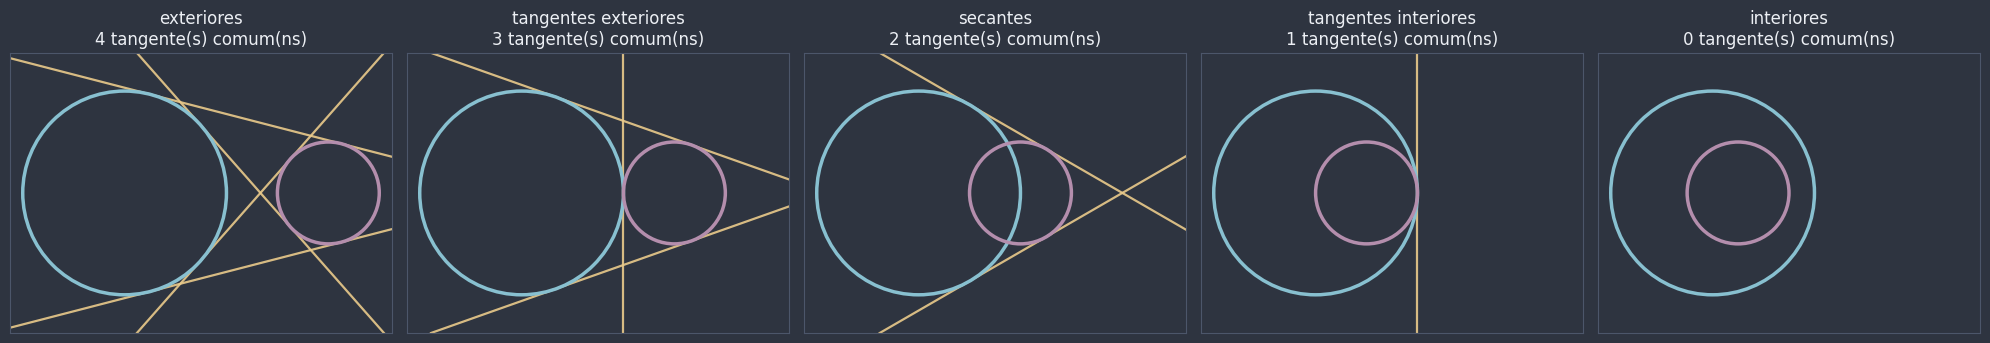

{'exteriores': 4, 'tangentes exteriores': 3, 'secantes': 2, 'tangentes interiores': 1, 'interiores': 0, 'concêntricas': 0}


In [8]:
# (a) O dicionário da tabela acima
tangentes_comuns_ex7 = {
    "exteriores": 4, "tangentes exteriores": 3, "secantes": 2,
    "tangentes interiores": 1, "interiores": 0, "concêntricas": 0,
}


# (b) A posição relativa decide tudo
def num_tangentes_comuns_ex7(O1, r1: float, O2, r2: float) -> int:
    return tangentes_comuns_ex7[posicao_circunferencias(O1, r1, O2, r2)]


# Conferência por código: encontrar as tangentes comuns de verdade.
# Uma reta com direção normal n (vetor de tamanho 1) é tangente a λ(O, r) quando a distância de O a ela é r. Com a
# reta escrita como "n · X = k", isso vira n · O1 = k ± r1 e n · O2 = k ± r2. Subtraindo, n · (O1 − O2) = r1 − s·r2,
# com s = +1 (tangente exterior: os centros do mesmo lado) ou s = −1 (interior: lados opostos). Como n · (O1 − O2) é
# no máximo d = O1O2, a equação tem 2 soluções se |r1 − s·r2| < d, 1 se for igual e 0 se for maior.
# (A conta completa é Geometria Analítica, módulo 07, e usa cosseno, da Trigonometria, módulo 05.)
def tangentes_comuns(O1, r1: float, O2, r2: float) -> list[tuple[np.ndarray, float]]:
    """Lista das tangentes comuns, cada uma como (um ponto da reta, inclinação em graus)."""
    O1, O2 = np.asarray(O1, dtype=float), np.asarray(O2, dtype=float)
    D = O1 - O2
    d, fi = np.linalg.norm(D), math.degrees(math.atan2(D[1], D[0]))
    retas = []
    for s in (+1, -1):
        alvo = r1 - s * r2
        if d < 1e-12 or abs(alvo) > d + 1e-9:
            continue
        abertura = math.degrees(math.acos(np.clip(alvo / d, -1, 1)))
        for angulo_normal in sorted({round(fi + abertura, 9), round(fi - abertura, 9)}):
            n = direcao(angulo_normal)
            T1 = O1 - r1 * n  # o ponto de tangência na primeira circunferência
            retas.append((T1, angulo_normal + 90))
    return retas


fig, eixos = plt.subplots(1, 5, figsize=(20, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, d in zip(eixos, [8.0, 6.0, 4.0, 2.0, 1.0]):
    O1, O2, r1, r2 = np.array([0.0, 0.0]), np.array([d, 0.0]), 4.0, 2.0
    posicao = posicao_circunferencias(O1, r1, O2, r2)
    retas = tangentes_comuns(O1, r1, O2, r2)
    assert len(retas) == num_tangentes_comuns_ex7(O1, r1, O2, r2)
    preparar_eixo(ax, [(-4.5, -5.5), (10.5, 5.5)], margem=0)
    for ponto, inclinacao in retas:
        desenhar_reta(ax, ponto, ponto + direcao(inclinacao), cor=COR_AVISO, largura=1.6)
    desenhar_circunferencia(ax, O1, r1)
    desenhar_circunferencia(ax, O2, r2, cor=COR_CIRCUNFERENCIA_2)
    ax.set_title(f"{posicao}\n{len(retas)} tangente(s) comum(ns)", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()
print(tangentes_comuns_ex7)

🎯 **De volta às polias:** as tangentes exteriores são o caminho de uma **correia aberta** (as duas polias giram no mesmo sentido), e as tangentes interiores, o de uma **correia cruzada** (as polias giram em sentidos contrários). Por isso uma correia cruzada só é possível quando as polias estão **afastadas** (circunferências exteriores): se elas se cortassem, não haveria tangente interior por onde a correia passar.